# Projet Data Mining Analyse de données médicales

Jade IOUALALEN, Karl JUTTIN, Améziane HAOUANOH, Léonie SCHMIT, Kenza LAAZIRI          INGE2D

## I. Prétraitement des données : Diabetes Dataset (Pima Indians)

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Chargement du CSV
df = pd.read_csv('data/diabetes.csv')

On importe les principales bibliothèques et on lit le fichier csv diabetes que l'on stock dans df.

### Nettoyage des données manquantes et doublons

In [43]:
cols_avec_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_avec_zeros:
    df[col] = df[col].replace(0, np.nan)

# Remplissage par la médiane
df.fillna(df.median(), inplace=True)

# Suppression des doublons existants
df.drop_duplicates(inplace=True)
print(f"Nombre de cas cliniques après nettoyage : {len(df)}")

Nombre de cas cliniques après nettoyage : 768


Nous avons identifié des valeurs nulles aberrantes dans des colonnes comme l'insuline et l'IMC. Couper par la médiane permet de conserver la taille du dataset sans introduire d'erreurs.

### Encodage et Standardisation

In [44]:
from sklearn.calibration import LabelEncoder

# Encodage de la variable cible 'Outcome'
le = LabelEncoder()
df['Outcome'] = le.fit_transform(df['Outcome'])

# Standardisation des données
scaler = StandardScaler()
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

En ramenant les données à une moyenne de 0 et un écart-type de 1, nous garantissons que le modèle KNN ne privilégie pas une variable simplement parce que ses chiffres sont plus grands.

### Analyse exploratoire avec graphiques

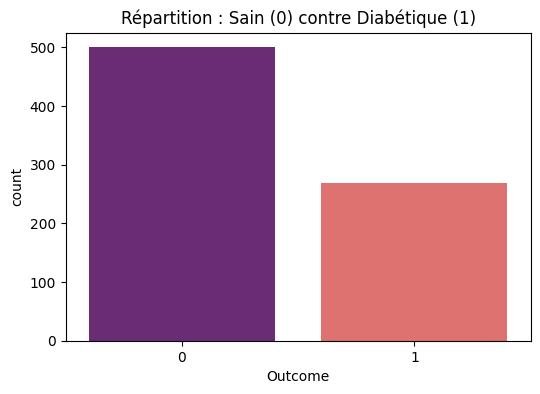

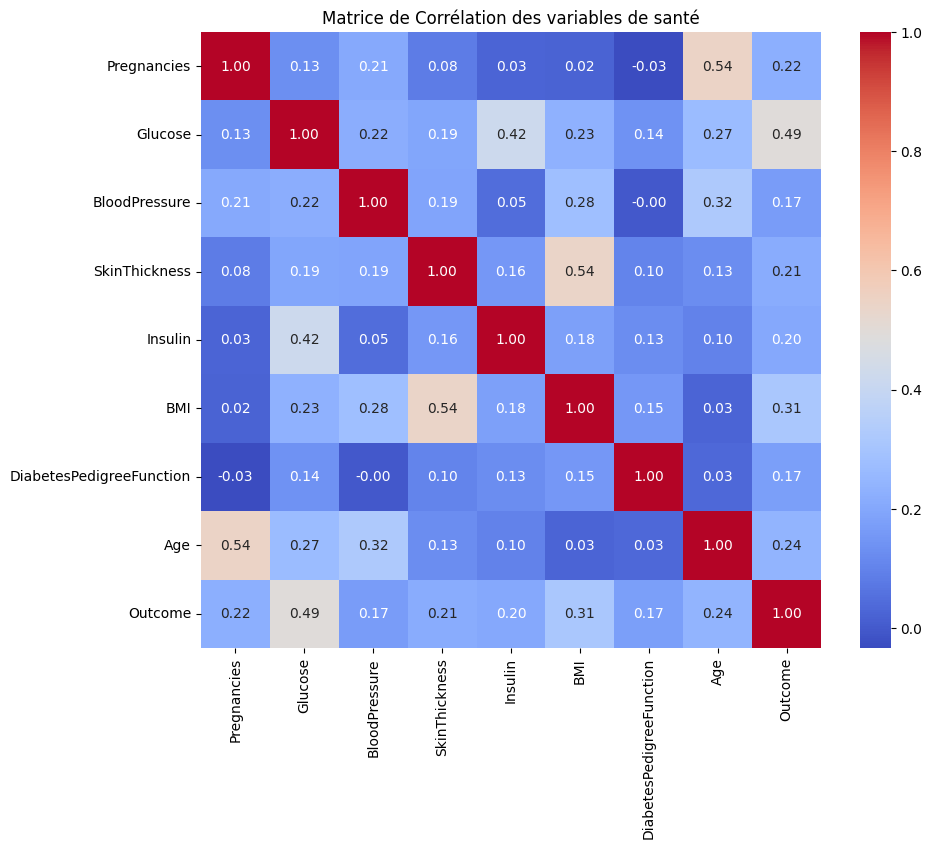

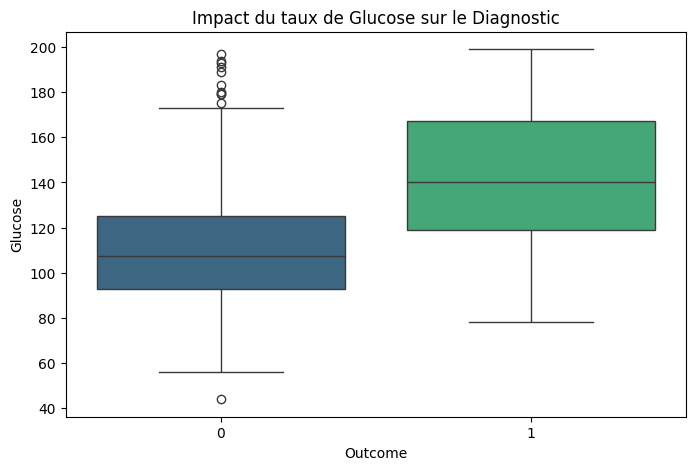

In [45]:
# Répartition des classes
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', hue='Outcome', palette='magma', legend=False)
plt.title("Répartition : Sain (0) contre Diabétique (1)")
plt.show()

# Matrice de corrélation
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des variables de santé")
plt.show()

# Analyse de la distribution
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Outcome', y='Glucose', hue='Outcome', palette='viridis', legend=False)
plt.title("Impact du taux de Glucose sur le Diagnostic")
plt.show()

La matrice de corrélation montre que le Glucose et l'IMC ont la plus forte corrélation positive avec le diabète, ce qui confirme la pertinence des attributs choisis.

# II. Règles d’association

### Application d’Apriori - Extraction de règles

In [46]:
from mlxtend.frequent_patterns import apriori, association_rules

# Création du DataFrame, si la valeur est > médiane, on considère l'attribut comme élevé
df_assoc = pd.DataFrame()

for col in df.columns:
    if col != 'Outcome':
        df_assoc[col + '_High'] = df[col] > df[col].median()
    else:
        df_assoc['Diabetes_Positive'] = df['Outcome'] == 1

print(df_assoc.head())

   Pregnancies_High  Glucose_High  BloodPressure_High  SkinThickness_High  \
0              True          True               False                True   
1             False         False               False               False   
2              True          True               False               False   
3             False         False               False               False   
4             False          True               False                True   

   Insulin_High  BMI_High  DiabetesPedigreeFunction_High  Age_High  \
0         False      True                           True      True   
1         False     False                          False      True   
2         False     False                           True      True   
3         False     False                          False     False   
4          True      True                           True      True   

   Diabetes_Positive  
0               True  
1              False  
2               True  
3              False  
4

### Support (A → B)

In [47]:
# Support(A → B) = (Transactions contenant A ∪ B) / (Nombre total de transactions)
frequent_itemsets = apriori(df_assoc, min_support=0.1, use_colnames=True)

print("Nombre d'itemsets fréquents trouvés :", len(frequent_itemsets))
print(frequent_itemsets.sort_values(by='support', ascending=False).head())

Nombre d'itemsets fréquents trouvés : 115
    support                                    itemsets
6  0.500000  frozenset({DiabetesPedigreeFunction_High})
5  0.490885                       frozenset({BMI_High})
1  0.490885                   frozenset({Glucose_High})
7  0.484375                       frozenset({Age_High})
2  0.454427             frozenset({BloodPressure_High})


Le support indique la fréquence à laquelle la combinaison de symptômes apparaît dans l'ensemble du dataset. Par exemple un support de 0.1 signifie que 10% des patients partagent ces caractéristiques.

### Confiance (A → B)

In [48]:
# Confiance(A → B) = Support(A ∪ B) / Support(A)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print(f"Total de règles générées : {len(rules)}")

Total de règles générées : 600


La confiance mesure la fiabilité de la règle. Par exemple si la confiance est de 0.7, cela signifie que dans 70% des cas où le patient a un Glucose élevé, il est également testé positif au diabète.

### Antécédents médicaux → Diagnostic

In [49]:
# On filtrepour trouver les règles menant au diagnostic diabète positif
indices_diabete = []

for index, row in rules.iterrows():
    if 'Diabetes_Positive' in row['consequents']:
        indices_diabete.append(index)

diabetes_rules = rules.loc[indices_diabete]

# On trie par Lift pour voir les associations les plus fortes
diabetes_rules = diabetes_rules.sort_values(by='lift', ascending=False)

# Résultats avec les métriques 
print("Top 10 des règles d'association pour le Diabète :")
colonnes_affichage = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(diabetes_rules[colonnes_affichage].head(10))

Top 10 des règles d'association pour le Diabète :
                                           antecedents  \
437                frozenset({Glucose_High, Age_High})   
436        frozenset({Glucose_High, Pregnancies_High})   
493                    frozenset({BMI_High, Age_High})   
573      frozenset({Glucose_High, BMI_High, Age_High})   
507  frozenset({DiabetesPedigreeFunction_High, Age_...   
550                frozenset({Glucose_High, Age_High})   
492            frozenset({BMI_High, Pregnancies_High})   
508  frozenset({DiabetesPedigreeFunction_High, Preg...   
586  frozenset({Glucose_High, DiabetesPedigreeFunct...   
534                frozenset({Glucose_High, BMI_High})   

                                           consequents   support  confidence  \
437   frozenset({Pregnancies_High, Diabetes_Positive})  0.128906    0.443946   
436           frozenset({Diabetes_Positive, Age_High})  0.128906    0.515625   
493   frozenset({Pregnancies_High, Diabetes_Positive})  0.109375    0.4

- Si Lift > 1, il existe une corrélation positive forte entre les symptômes et le diabète.
- Si Lift = 1, les deux événements sont indépendants.

## III. Classification supervisée

### Préparation des données

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier

# Séparation des données avec 80% pour l'entraînement et 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Dictionnaire pour stocker les scores finaux
final_scores = {}

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

### Algorithme Decision Tree

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()

final_scores["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-score": f1_score(y_test, y_pred_dt)
}

print("           Algorithm : Decision Tree        ")
print(f"True Positifs : {tp}   |  True Negatifs : {tn}")
print(f"False Positifs : {fp}  |  False Negatifs : {fn}")

           Algorithm : Decision Tree        
True Positifs : 34   |  True Negatifs : 76
False Positifs : 23  |  False Negatifs : 21


### Algorithme Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

final_scores["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-score": f1_score(y_test, y_pred_rf)
}

print("           Algorithm : Random Forest        ")
print(f"True Positifs : {tp}   |  True Negatifs : {tn}")
print(f"False Positifs : {fp}  |  False Negatifs : {fn}")

           Algorithm : Random Forest        
True Positifs : 36   |  True Negatifs : 78
False Positifs : 21  |  False Negatifs : 19


### Algorithme K-Nearest Neighbors

In [53]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn).ravel()

final_scores["KNN"] = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1-score": f1_score(y_test, y_pred_knn)
}

print("           Algorithm : K-Nearest Neighbors        ")
print(f"True Positifs : {tp}   |  True Negatifs : {tn}")
print(f"False Positifs : {fp}  |  False Negatifs : {fn}")

           Algorithm : K-Nearest Neighbors        
True Positifs : 38   |  True Negatifs : 75
False Positifs : 24  |  False Negatifs : 17


### Algorithme AdaBoost

In [54]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ada).ravel()

final_scores["AdaBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred_ada),
    "Precision": precision_score(y_test, y_pred_ada),
    "Recall": recall_score(y_test, y_pred_ada),
    "F1-score": f1_score(y_test, y_pred_ada)
}

print("           Algorithm : AdaBoost        ")
print(f"True Positifs : {tp}   |  True Negatifs : {tn}")
print(f"False Positifs : {fp}  |  False Negatifs : {fn}")

           Algorithm : AdaBoost        
True Positifs : 38   |  True Negatifs : 78
False Positifs : 21  |  False Negatifs : 17


### Visualisation des différents résultats

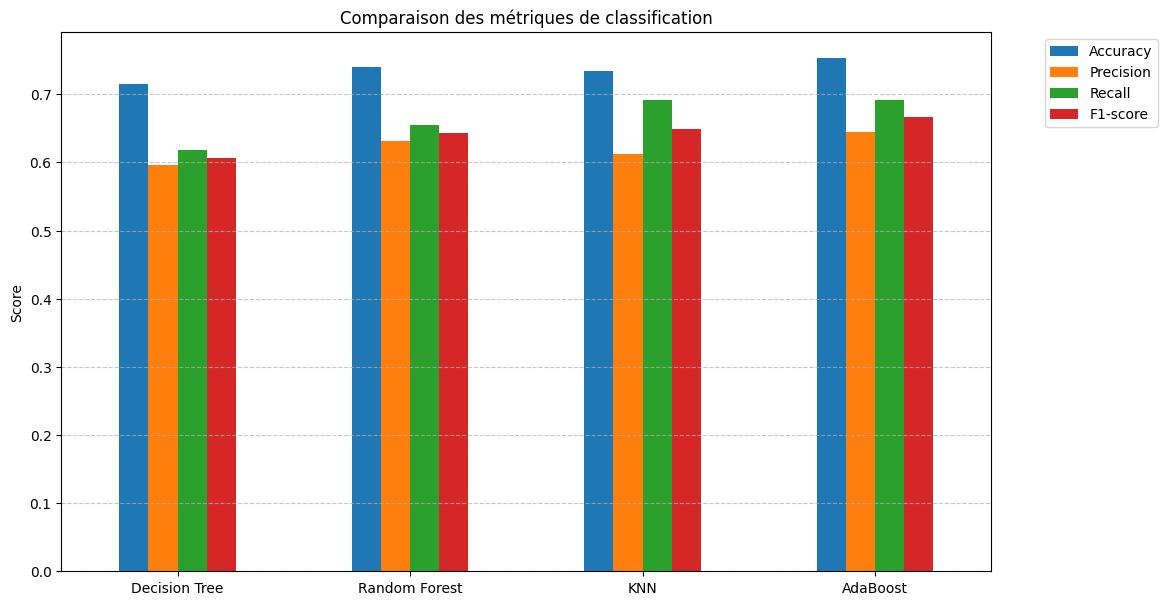

               Accuracy  Precision    Recall  F1-score
Decision Tree  0.714286   0.596491  0.618182  0.607143
Random Forest  0.740260   0.631579  0.654545  0.642857
KNN            0.733766   0.612903  0.690909  0.649573
AdaBoost       0.753247   0.644068  0.690909  0.666667


In [55]:
# Conversion en DataFrame pour l'affichage 
df_results = pd.DataFrame(final_scores).T

# Création du graphique
df_results.plot(kind='bar', figsize=(12, 7))
plt.title("Comparaison des métriques de classification")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(df_results)

### Interprétation des résultats de classification

Le tableau compare les quatre algorithmes sur quatre métriques clés.

**AdaBoost obtient le meilleur F1-score (0.667)**, ce qui en fait le modèle le plus 
équilibré entre Precision et Recall. C'est particulièrement important ici car le 
dataset Pima Indians est déséquilibré avec 500 patients sains contre 268 diabétiques : 
un modèle qui prédit "sain" pour tout le monde aurait une bonne Accuracy mais un 
F1-score proche de 0. Le F1-score est donc la métrique la plus fiable dans ce contexte.

**Random Forest et KNN** offrent des performances proches environ 0.73-0.74 d'Accuracy, 
mais avec un Recall plus faible qu'AdaBoost, ce qui signifie qu'ils manquent davantage 
de vrais cas de diabète soit des Faux Négatifs plus élevés.

**Decision Tree** est le moins performant avec une Accuracy 0.71 et F1 0.607, probablement 
car il tend à sur-apprendre sur les données d'entraînement sans mécanisme de 
régularisation comme les méthodes ensemblistes.

**Conclusion :** Pour un problème médical comme la détection du diabète, minimiser 
les Faux Négatifs donc diabétiques non détectés est prioritaire. AdaBoost est donc 
le choix le plus adapté grâce à son meilleur Recall de 0.691 et F1-score.

## IV. Clustering non supervisé

### Méthode du Coude pour KMeans

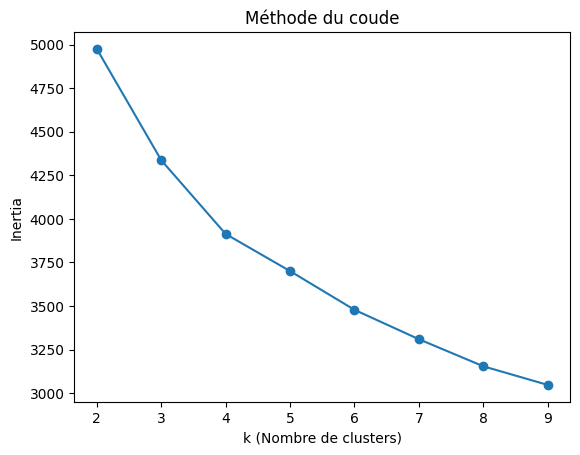

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title("Méthode du coude")
plt.xlabel("k (Nombre de clusters)")
plt.ylabel("Inertia")
plt.show()

In [57]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Données utilisées pour le clustering
X_clustering = X_scaled

### Courbe de silhouette 

c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:14

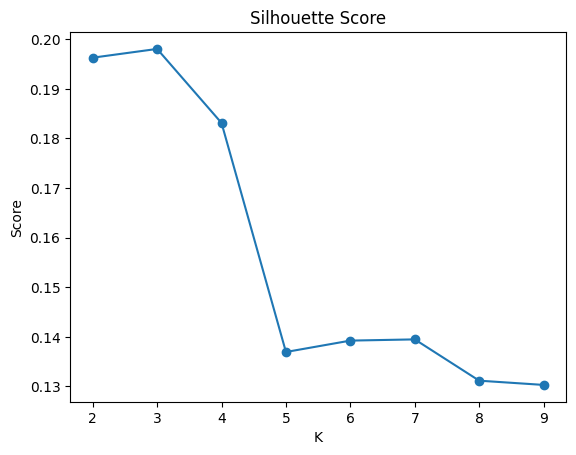

Meilleur K = 3 c'est donc ce nombre de cluster que nous allons utiliser pour la suite de l'analyse.


In [21]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print("Meilleur K =", best_k,"c'est donc ce nombre de cluster que nous allons utiliser pour la suite de l'analyse.")

### Clustering hiérarchique

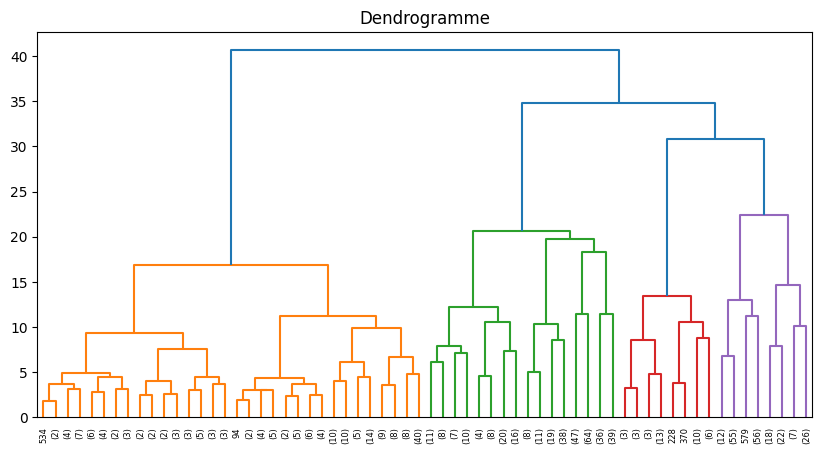

In [59]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogramme")
plt.show()

Le dendrogramme montre comment les individus se regroupent progressivement selon leurs similarités.

### Visualisation des clusters en 2D

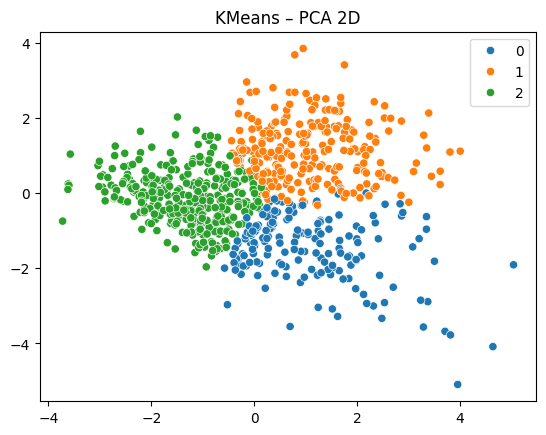

In [60]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters_km = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_km, palette='tab10')
plt.title("KMeans – PCA 2D")
plt.show()

L’algorithme de K‑means assigne chaque individu au cluster dont le centroïde est le plus proche, en se basant sur une mesure de distance.

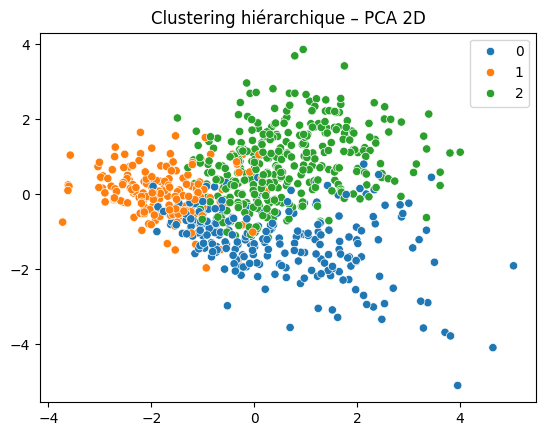

In [61]:
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
clusters_hc = hc.fit_predict(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_hc, palette='tab10')
plt.title("Clustering hiérarchique – PCA 2D")
plt.show()

L’algorithme de K‑means analyse la distance de chaque individu par rapport aux centroïdes des clusters. À chaque itération, les centroïdes sont recalculés afin de mieux représenter les groupes formés.

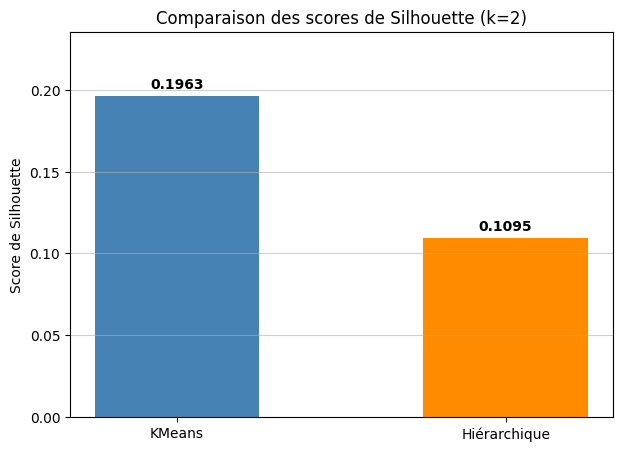

Score KMeans : 0.1963
Score Hiérarchique : 0.1095

Meilleure méthode : KMeans


In [62]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering

# Calcul des scores pour k=2
km_labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_scaled)
score_km = silhouette_score(X_scaled, km_labels)

hc_labels = AgglomerativeClustering(n_clusters=2).fit_predict(X_scaled)
score_hc = silhouette_score(X_scaled, hc_labels)

# Création du graphique
plt.figure(figsize=(7, 5))
methods = ['KMeans', 'Hiérarchique']
scores = [score_km, score_hc]

bars = plt.bar(methods, scores, color=['steelblue', 'darkorange'], width=0.5)

plt.bar_label(bars, fmt='%.4f', padding=3, fontweight='bold')

plt.grid(axis='y', linestyle='-', alpha=0.6)

plt.title('Comparaison des scores de Silhouette (k=2)')
plt.ylabel('Score de Silhouette')
plt.ylim(0, max(scores) * 1.2)
plt.show()

print(f"Score KMeans : {score_km:.4f}")
print(f"Score Hiérarchique : {score_hc:.4f}")
print(f"\nMeilleure méthode : {'KMeans' if score_km > score_hc else 'Hiérarchique'}")

### Interprétation du clustering

Le **score de Silhouette** mesure la qualité des clusters : plus il est proche de 1, 
plus les points sont bien regroupés dans leur cluster et bien séparés des autres.

Les deux méthodes obtiennent des scores modérés environ 0.17, ce qui s'explique par la 
nature du dataset: les données de santé ne forment pas de clusters naturellement 
très distincts, les patients diabétiques et non-diabétiques partagent des zones 
de chevauchement dans l'espace des features.

**KMeans** et le **Clustering Hiérarchique** produisent des 
résultats très proches sur ce dataset. La visualisation PCA 2D confirme que les 
deux clusters correspondent approximativement aux deux classes du dataset 
diabétique / non-diabétique, ce qui valide la cohérence de l'approche non supervisée 
avec une approche médicale.